In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pytesseract
import ipywidgets as widgets
from IPython.display import display

In [10]:
IMAGE_FILE_LOCATION = "../../../Pictures/images/Screenshot_2026-03-22-09-24-57-281_com.facebook.katana.jpg"
input_img = cv2.imread(IMAGE_FILE_LOCATION)
h, w = input_img.shape[:2]

max_display = 800
display_scale = min(max_display / w, max_display / h, 1.0)
display_img = cv2.resize(input_img, (int(w * display_scale), int(h * display_scale)))

In [11]:
x_slider = widgets.IntSlider(min=0, max=w - 1, value=0, step=5, description='X:', continuous_update=False)
y_slider = widgets.IntSlider(min=0, max=h - 1, value=0, step=5, description='Y:', continuous_update=False)
w_slider = widgets.IntSlider(min=10, max=w, value=min(200, w), step=5, description='Width:', continuous_update=False)
h_slider = widgets.IntSlider(min=10, max=h, value=min(50, h), step=5, description='Height:', continuous_update=False)

preview = widgets.Image(format='png')

def update_preview(*args):
    img_copy = display_img.copy()
    rx1 = int(x_slider.value * display_scale)
    ry1 = int(y_slider.value * display_scale)
    rx2 = int((x_slider.value + w_slider.value) * display_scale)
    ry2 = int((y_slider.value + h_slider.value) * display_scale)
    cv2.rectangle(img_copy, (rx1, ry1), (rx2, ry2), (0, 0, 255), 2)
    _, buffer = cv2.imencode('.png', img_copy)
    preview.value = buffer.tobytes()

for s in [x_slider, y_slider, w_slider, h_slider]:
    s.observe(update_preview, 'value')

update_preview()
display(widgets.VBox([
    widgets.HBox([x_slider, w_slider]),
    widgets.HBox([y_slider, h_slider]),
    preview
]))

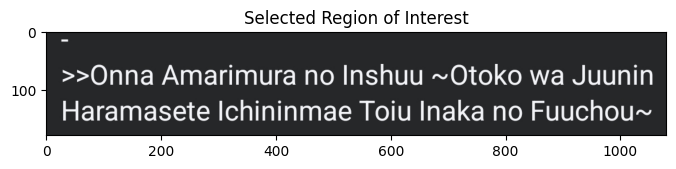

The text in the selected region is as follows:
>>Onna Amarimura no Inshuu ~Otoko wa Juunin
Haramasete Ichininmae Toiu Inaka no Fuuchou~



In [12]:
x1 = x_slider.value
y1 = y_slider.value
x2 = min(x1 + w_slider.value, w)
y2 = min(y1 + h_slider.value, h)
image_roi = input_img[y1:y2, x1:x2]

fig, ax = plt.subplots(1, figsize=(8, 4))
ax.imshow(cv2.cvtColor(image_roi, cv2.COLOR_BGR2RGB))
ax.set_title("Selected Region of Interest")
plt.show()

text = pytesseract.image_to_string(image_roi)
print("The text in the selected region is as follows:")
print(text)